In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **WEEK1:Data Preprocessing**

In [45]:
df=pd.read_csv('b2b_sla_logistics_dataset_200k.csv')

In [46]:
df.head()

,shipment_id,carrier,shipping_mode,region,origin_country,destination_country,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,...,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,shipping_cost_usd,fuel_surcharge_pct,customs_delay_flag,weather_disruption_flag,shipment_value_usd,insurance_flag
0,SHP_1000000,Carrier_H,Rail,EMEA,France,UK,9256.28,100.28,0,0,...,23,24.0,1.0,1,9531.05,20.18,1,0,48235.35,0
1,SHP_1000001,Carrier_E,Rail,APAC,Vietnam,UK,11026.85,85.39,0,0,...,39,36.0,-3.0,0,6249.19,24.71,0,0,44935.84,1
2,SHP_1000002,Carrier_B,Road,AMER,Vietnam,Germany,9126.25,137.58,0,0,...,7,7.0,0.0,0,11949.56,12.06,0,0,90132.88,0
3,SHP_1000003,Carrier_G,Road,AMER,Mexico,USA,6327.51,51.24,0,0,...,18,15.0,-3.0,0,11227.29,23.35,0,0,84935.19,1
4,SHP_1000004,Carrier_D,Road,EMEA,Poland,China,8850.45,109.66,0,0,...,19,20.0,1.0,1,9746.15,11.44,0,0,62812.24,0


In [47]:
df.tail()

,shipment_id,carrier,shipping_mode,region,origin_country,destination_country,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,...,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,shipping_cost_usd,fuel_surcharge_pct,customs_delay_flag,weather_disruption_flag,shipment_value_usd,insurance_flag
199995,SHP_1199995,Carrier_B,Sea,APAC,France,Germany,9259.09,19.20,0,0,...,8,7.0,-1.0,0,3241.09,16.66,0,0,33174.26,0
199996,SHP_1199996,Carrier_D,Sea,AMER,USA,Poland,272.39,80.01,0,0,...,11,14.0,3.0,1,968.00,23.03,0,0,6515.07,1
199997,SHP_1199997,Carrier_H,Sea,AMER,China,UK,3836.31,72.21,0,0,...,27,35.0,8.0,1,4403.56,24.33,0,0,19805.72,1
199998,SHP_1199998,Carrier_F,Sea,EMEA,China,USA,8427.47,103.50,0,1,...,8,9.0,1.0,1,5032.02,15.21,0,0,40751.98,1
199999,SHP_1199999,Carrier_G,Sea,APAC,France,Vietnam,7294.08,116.74,0,1,...,6,7.0,1.0,1,6719.27,15.63,0,0,34694.94,0


In [48]:
df.columns

Index(['shipment_id', 'carrier', 'shipping_mode', 'region', 'origin_country',
       'destination_country', 'shipment_weight_kg', 'shipment_volume_cbm',
       'priority_flag', 'fragile_flag', 'temperature_control_flag',
       'planned_delivery_days', 'actual_delivery_days', 'delivery_delay_days',
       'sla_breach_flag', 'shipping_cost_usd', 'fuel_surcharge_pct',
       'customs_delay_flag', 'weather_disruption_flag', 'shipment_value_usd',
       'insurance_flag'],
      dtype='object')

In [49]:
df.shape

(200000, 21)

# **MetaData**

- Shipment_id=unique shipment identifier
- carrier=carrier name
- shippping_mode=the model of the shipping (sea,road ,air..)
- region:The macro geographic area
- origin_country=the contry of origin
- destination_country= the country of destination
- shipment _weight_kg=the weights of the shipment
- shipement_volume_cbm=the volume of the shipment
- priority_flag=wether the shipment has a priority or not to be shipped
- fragile_flag=wether the shipment is fragile
- planned_delivery_day= how many days planned for the shipping
- actuak_delivery_days=how many days actually took for the shipping
- delivery_delay_days=how many days delayed to be delivered
- SLA breach flag=wether the SLA is breached or not
- shipping_cost_usd=the cost of the shipping is US dollars

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   shipment_id               200000 non-null  object 
 1   carrier                   200000 non-null  object 
 2   shipping_mode             200000 non-null  object 
 3   region                    200000 non-null  object 
 4   origin_country            200000 non-null  object 
 5   destination_country       200000 non-null  object 
 6   shipment_weight_kg        200000 non-null  float64
 7   shipment_volume_cbm       200000 non-null  float64
 8   priority_flag             200000 non-null  int64  
 9   fragile_flag              200000 non-null  int64  
 10  temperature_control_flag  200000 non-null  int64  
 11  planned_delivery_days     200000 non-null  int64  
 12  actual_delivery_days      200000 non-null  float64
 13  delivery_delay_days       200000 non-null  f

**Note:**
-  Actual_delivery_days and delivery_delay_days should be converted into integer datatype

In [51]:
df.describe()

,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,temperature_control_flag,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,shipping_cost_usd,fuel_surcharge_pct,customs_delay_flag,weather_disruption_flag,shipment_value_usd,insurance_flag
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,6011.186382,75.041744,0.280330,0.180620,0.101215,23.021875,23.313910,0.292035,0.472355,6933.771655,14.989707,0.120515,0.101025,51981.725429,0.350125
std,3460.985408,43.289321,0.449162,0.384704,0.301614,12.417750,12.961707,4.034554,0.499236,5128.662432,5.767467,0.325564,0.301363,44439.213938,0.477010
min,10.050000,0.200000,0.000000,0.000000,0.000000,2.000000,1.000000,-19.000000,0.000000,17.800000,5.000000,0.000000,0.000000,118.940000,0.000000
25%,3016.507500,37.480000,0.000000,0.000000,0.000000,12.000000,12.000000,-2.000000,0.000000,3254.477500,9.990000,0.000000,0.000000,21265.632500,0.000000
50%,6018.545000,75.055000,0.000000,0.000000,0.000000,23.000000,23.000000,0.000000,0.000000,5678.730000,14.990000,0.000000,0.000000,39325.225000,0.000000
75%,9003.557500,112.500000,1.000000,0.000000,0.000000,34.000000,34.000000,3.000000,1.000000,9252.337500,19.980000,0.000000,0.000000,68794.112500,1.000000
max,11999.980000,150.000000,1.000000,1.000000,1.000000,44.000000,59.000000,20.000000,1.000000,40387.720000,25.000000,1.000000,1.000000,424491.070000,1.000000


**Notes**
- Apparently all the columns contain 200000 records which indicate no missing vales .
- the maximum delivery_delay_days is 20 days
- the standard deviation of delivery_delay_days is 4 days ,and mean od 0.29" 7 hours" which means high valatility and unpredictibility in carrier performance
- the maximux actual delivery days is 59 days
- the minimum planned_delivery_days is 2 days
- the everage of actual_delivery_days is 23 days
- the average shipping cost is 6933 USD
- the maximum shipping_cost is 40387 USD and the 75th percentile is 9252 USD, that's  indicate either an outlier or a premium air shipping
- the maximum shipment_weight is 11999 kg
- 25% of the shipment are actually delivered in12 days ,and the 75% are shipped in 34 days , while the maximun is 59 days

In [52]:
df.isnull().sum()

,0
shipment_id,0
carrier,0
shipping_mode,0
region,0
origin_country,0
destination_country,0
shipment_weight_kg,0
shipment_volume_cbm,0
priority_flag,0
fragile_flag,0


- the dataset has no missing values

In [53]:
#print how many duplictes are there in the dataset
df.duplicated().sum()

np.int64(0)

# **data type correction**

In [54]:
df.dtypes

,0
shipment_id,object
carrier,object
shipping_mode,object
region,object
origin_country,object
destination_country,object
shipment_weight_kg,float64
shipment_volume_cbm,float64
priority_flag,int64
fragile_flag,int64


- Before converting let's checks if planned_delivery_days and actual_delivery_days contain any negative values

In [55]:
nagative_planned=(df['planned_delivery_days']<0).sum()
negative_actual=(df['actual_delivery_days']<0).sum()
negative_costs=(df['shipping_cost_usd']<0).sum()
print(negative_costs,nagative_planned,negative_actual)

0 0 0


In [56]:
#converting actual planned_days and delivery_delay to integer datatype
df['actual_delivery_days']=df['actual_delivery_days'].astype(int)
df['delivery_delay_days']=df['delivery_delay_days'].astype(int)

In [57]:
df.dtypes

,0
shipment_id,object
carrier,object
shipping_mode,object
region,object
origin_country,object
destination_country,object
shipment_weight_kg,float64
shipment_volume_cbm,float64
priority_flag,int64
fragile_flag,int64


In [58]:
df.head(10)

,shipment_id,carrier,shipping_mode,region,origin_country,destination_country,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,...,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,shipping_cost_usd,fuel_surcharge_pct,customs_delay_flag,weather_disruption_flag,shipment_value_usd,insurance_flag
0,SHP_1000000,Carrier_H,Rail,EMEA,France,UK,9256.28,100.28,0,0,...,23,24,1,1,9531.05,20.18,1,0,48235.35,0
1,SHP_1000001,Carrier_E,Rail,APAC,Vietnam,UK,11026.85,85.39,0,0,...,39,36,-3,0,6249.19,24.71,0,0,44935.84,1
2,SHP_1000002,Carrier_B,Road,AMER,Vietnam,Germany,9126.25,137.58,0,0,...,7,7,0,0,11949.56,12.06,0,0,90132.88,0
3,SHP_1000003,Carrier_G,Road,AMER,Mexico,USA,6327.51,51.24,0,0,...,18,15,-3,0,11227.29,23.35,0,0,84935.19,1
4,SHP_1000004,Carrier_D,Road,EMEA,Poland,China,8850.45,109.66,0,0,...,19,20,1,1,9746.15,11.44,0,0,62812.24,0
5,SHP_1000005,Carrier_D,Rail,APAC,UK,China,10982.94,41.84,0,0,...,24,17,-7,0,14786.19,11.39,0,0,156181.82,1
6,SHP_1000006,Carrier_H,Road,EMEA,Mexico,UK,1857.41,94.84,0,0,...,28,23,-5,0,3115.40,14.15,0,0,16176.09,0
7,SHP_1000007,Carrier_H,Air,AMER,UAE,Vietnam,3128.40,91.66,0,0,...,8,7,-1,0,5486.73,15.81,0,0,18794.00,1
8,SHP_1000008,Carrier_E,Road,EMEA,UAE,USA,10814.58,145.36,1,0,...,5,11,6,1,11729.77,5.54,0,0,68975.02,1
9,SHP_1000009,Carrier_B,Air,APAC,Poland,Vietnam,9142.06,101.52,1,0,...,14,15,1,1,9678.98,11.64,1,0,88717.54,0


# **Target Variable creation**

In [59]:
#creating ans SLA breach flag
df['SLA_breach_flag']=(df["actual_delivery_days"]> df["planned_delivery_days"]).astype(int)


In [60]:
#print the 5 first records where SLA_breach equal to 0
df[df['SLA_breach_flag']==0].head()[['planned_delivery_days','actual_delivery_days','delivery_delay_days']]


,planned_delivery_days,actual_delivery_days,delivery_delay_days
1,39,36,-3
2,7,7,0
3,18,15,-3
5,24,17,-7
6,28,23,-5


In [61]:
df[df['SLA_breach_flag']==1].head()[['planned_delivery_days','actual_delivery_days','delivery_delay_days']]

,planned_delivery_days,actual_delivery_days,delivery_delay_days
0,23,24,1
4,19,20,1
8,5,11,6
9,14,15,1
12,18,21,3


# **Data Encoding**
- We will be using one hot-Encoding or label-encoding to encode our categorical variables
- the columns should be encoded are: Vendor ,shipping_mode,region,origin_country, destination country

In [62]:
df["carrier"].value_counts()

,count
carrier,
Carrier_G,25236
Carrier_C,25163
Carrier_A,25133
Carrier_D,24998
Carrier_F,24944
Carrier_E,24915
Carrier_H,24839
Carrier_B,24772


In [63]:
df["shipping_mode"].value_counts()

,count
shipping_mode,
Road,79550
Sea,60329
Air,40035
Rail,20086


In [64]:
df["region"].value_counts()

,count
region,
EMEA,66922
APAC,66849
AMER,66229


In [65]:
df["origin_country"].value_counts()

,count
origin_country,
USA,20136
Germany,20084
UAE,20033
Mexico,20006
China,20004
Vietnam,19992
India,19954
Poland,19945
UK,19942


In [66]:
df["destination_country"].value_counts()

,count
destination_country,
France,20149
Vietnam,20121
China,20079
Poland,20041
UAE,20018
Mexico,20004
UK,20003
India,19932
Germany,19914


**Note**
- One-Hot Encoding transforms a single categorical column into multiple new columns, where each column represents one unique category with a value of 1 (Yes) or 0 (No), this is the ideal type of encoding for columns:region , carrier , shipping_mode since we they are nominal variables
- Label Encoding converts each unique category into a single unique integer (e.g., 0, 1, 2, 3) within the same column, this type of encoding is optional for columns like origin_county,destination_country.
- since we have only 10 countries , i will be using one hot encoding for the five categorical variables


In [67]:
#apply one hot encoding for 5 categorical columns
df_encoded=pd.get_dummies(df,columns=['region','carrier','shipping_mode','origin_country','destination_country'])
df_encoded.head()

,shipment_id,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,temperature_control_flag,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,...,destination_country_China,destination_country_France,destination_country_Germany,destination_country_India,destination_country_Mexico,destination_country_Poland,destination_country_UAE,destination_country_UK,destination_country_USA,destination_country_Vietnam
0,SHP_1000000,9256.28,100.28,0,0,1,23,24,1,1,...,False,False,False,False,False,False,False,True,False,False
1,SHP_1000001,11026.85,85.39,0,0,0,39,36,-3,0,...,False,False,False,False,False,False,False,True,False,False
2,SHP_1000002,9126.25,137.58,0,0,0,7,7,0,0,...,False,False,True,False,False,False,False,False,False,False
3,SHP_1000003,6327.51,51.24,0,0,0,18,15,-3,0,...,False,False,False,False,False,False,False,False,True,False
4,SHP_1000004,8850.45,109.66,0,0,0,19,20,1,1,...,True,False,False,False,False,False,False,False,False,False


In [68]:
df_encoded.shape

(200000, 52)

# **Handelling Outliers**


In [69]:
df_encoded.columns

Index(['shipment_id', 'shipment_weight_kg', 'shipment_volume_cbm',
       'priority_flag', 'fragile_flag', 'temperature_control_flag',
       'planned_delivery_days', 'actual_delivery_days', 'delivery_delay_days',
       'sla_breach_flag', 'shipping_cost_usd', 'fuel_surcharge_pct',
       'customs_delay_flag', 'weather_disruption_flag', 'shipment_value_usd',
       'insurance_flag', 'SLA_breach_flag', 'region_AMER', 'region_APAC',
       'region_EMEA', 'carrier_Carrier_A', 'carrier_Carrier_B',
       'carrier_Carrier_C', 'carrier_Carrier_D', 'carrier_Carrier_E',
       'carrier_Carrier_F', 'carrier_Carrier_G', 'carrier_Carrier_H',
       'shipping_mode_Air', 'shipping_mode_Rail', 'shipping_mode_Road',
       'shipping_mode_Sea', 'origin_country_China', 'origin_country_France',
       'origin_country_Germany', 'origin_country_India',
       'origin_country_Mexico', 'origin_country_Poland', 'origin_country_UAE',
       'origin_country_UK', 'origin_country_USA', 'origin_country_Vietnam',


-  i will beusing Inter Quantile Range for detecting outiers , and i will focusing on four columns ;deleivery_delay_days, shipping_cost_usd,volume_cb,weight_kg

In [70]:
#we will detect and handle outliers
outliers_cols=["delivery_delay_days","shipping_cost_usd","shipment_volume_cbm","shipment_weight_kg"]
#detect outlier in these columns
for col in outliers_cols:
  Q1=df_encoded[col].quantile(0.25)
  Q3=df_encoded[col].quantile(0.75)
  IQR=Q3-Q1
  upper_bound=Q3+1.5*IQR
  lower_bound=Q1-1.5*IQR
  #not every exterme value is an outlier that is we should detect in whcich column we have outliers and inspect more their existence ,
  #especifically in the column shipping _cost , some values are not extereme values but rather premium air shipping
  outliers=df_encoded[(df_encoded[col]>upper_bound) | (df_encoded[col]<lower_bound)]
  print(f"Number of outliers in {col}: {len(outliers)}")




Number of outliers in delivery_delay_days: 2694
Number of outliers in shipping_cost_usd: 7776
Number of outliers in shipment_volume_cbm: 0
Number of outliers in shipment_weight_kg: 0


- as we can see we have 7776 outliers in the shipping_cost_usd column , those values are not errors but represent premium air shipping


In [71]:
df_encoded.to_csv('cleaned_b2b_sla_logistics_dataset.csv', index=False)

In [72]:
#let's make sure that the dataset doesn't contain any negative values
df_encoded["shipping_cost_usd"]

,shipping_cost_usd
0,9531.05
1,6249.19
2,11949.56
3,11227.29
4,9746.15
...,...
199995,3241.09
199996,968.00
199997,4403.56
199998,5032.02


In [73]:
min_shipping_cost = df_encoded['shipping_cost_usd'].min()
print(f"Minimum value in 'shipping_cost_usd': {min_shipping_cost}")

Minimum value in 'shipping_cost_usd': 17.8


# **week 2 EDA:Exploratory Data Analysis**

- through EDA , i will investigate the dataset , analyzing trends , patterns and risks
- through it we can study and comprehend the relationships among different variables
- with the help of this EDA i will answer one most impostant business question :Where do SLA breaches happen most, and why?


**Task 1:** **SLA BREACH OVERVIEW**
 - i will be calculating the SLA breach rate for the 200k records



In [74]:
df_encoded.head(10)

,shipment_id,shipment_weight_kg,shipment_volume_cbm,priority_flag,fragile_flag,temperature_control_flag,planned_delivery_days,actual_delivery_days,delivery_delay_days,sla_breach_flag,...,destination_country_China,destination_country_France,destination_country_Germany,destination_country_India,destination_country_Mexico,destination_country_Poland,destination_country_UAE,destination_country_UK,destination_country_USA,destination_country_Vietnam
0,SHP_1000000,9256.28,100.28,0,0,1,23,24,1,1,...,False,False,False,False,False,False,False,True,False,False
1,SHP_1000001,11026.85,85.39,0,0,0,39,36,-3,0,...,False,False,False,False,False,False,False,True,False,False
2,SHP_1000002,9126.25,137.58,0,0,0,7,7,0,0,...,False,False,True,False,False,False,False,False,False,False
3,SHP_1000003,6327.51,51.24,0,0,0,18,15,-3,0,...,False,False,False,False,False,False,False,False,True,False
4,SHP_1000004,8850.45,109.66,0,0,0,19,20,1,1,...,True,False,False,False,False,False,False,False,False,False
5,SHP_1000005,10982.94,41.84,0,0,0,24,17,-7,0,...,True,False,False,False,False,False,False,False,False,False
6,SHP_1000006,1857.41,94.84,0,0,1,28,23,-5,0,...,False,False,False,False,False,False,False,True,False,False
7,SHP_1000007,3128.40,91.66,0,0,0,8,7,-1,0,...,False,False,False,False,False,False,False,False,False,True
8,SHP_1000008,10814.58,145.36,1,0,0,5,11,6,1,...,False,False,False,False,False,False,False,False,True,False
9,SHP_1000009,9142.06,101.52,1,0,0,14,15,1,1,...,False,False,False,False,False,False,False,False,False,True


In [75]:
df_encoded[["SLA_breach_flag","sla_breach_flag"]].head(15)


,SLA_breach_flag,sla_breach_flag
0,1,1
1,0,0
2,0,0
3,0,0
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


- i will drop one column , both of them represent the same thing


In [76]:
data=df_encoded.drop("SLA_breach_flag",axis=1)

In [77]:
data["sla_breach_flag"].head(10)

,sla_breach_flag
0,1
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,1
9,1


In [78]:
data["sla_breach_flag"].value_counts()

,count
sla_breach_flag,
0,105529
1,94471


<Axes: xlabel='sla_breach_flag'>

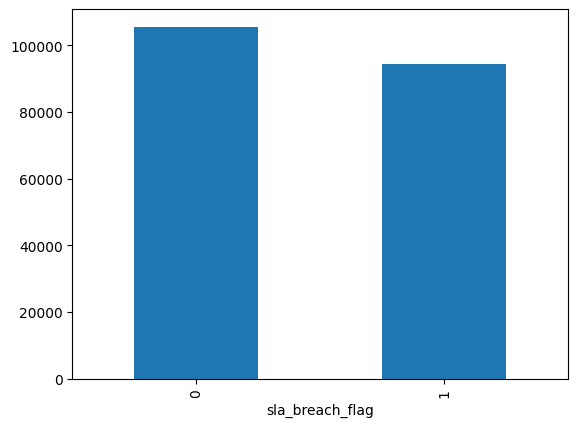

In [79]:
#visulize it in format of bar plot
data["sla_breach_flag"].value_counts().plot(kind="bar")

- In order to calculate the rate of the SLA breach , i will calculating the rate ,when sla_breach_flag is equal to 1 devided by total shipment .
- since this is a  binary column , the mean functions is mathmatically calculting it , i will just multiply it by 100 to get the percentage


In [80]:
sla_breach_rate=data["sla_breach_flag"].mean()*100
print(f"The SLA breach rate is {sla_breach_rate}%")

The SLA breach rate is 47.2355%


- 47% of the shipment breached and 53% are met
- The target variable is well-balanced, with 47% of shipments resulting in an SLA breach.
- This eliminates the risk of class imbalance bias in our predictive models.
 - However, from a business perspective, this high failure rate confirms a critical need for the proactive intelligence we are building to replace the current reactive monitoring system.
- in the next tasks , we will try to investigate why 47% of shipment are breached

**Task 2:CARRIER-LEVEL EDA**


In [81]:
# Get all carrier columns dynamically
carrier_columns = [col for col in data.columns if col.startswith('carrier_')]

# Dictionary to store SLA breaches per carrier
sla_breaches_per_carrier = {}

for carrier_col in carrier_columns:
    # Filter data for the current carrier
    carrier_data = data[data[carrier_col] == True]
    # Count SLA breaches for this carrier
    breaches = carrier_data['sla_breach_flag'].sum()
    sla_breaches_per_carrier[carrier_col.replace('carrier_', '')] = breaches

# Convert to a pandas Series for better display
sla_breaches_series = pd.Series(sla_breaches_per_carrier)

print("Number of SLA breaches for each carrier:")
display(sla_breaches_series.sort_values(ascending=False))

Number of SLA breaches for each carrier:


,0
Carrier_C,12023
Carrier_G,11909
Carrier_D,11848
Carrier_F,11785
Carrier_A,11767
Carrier_E,11748
Carrier_B,11732
Carrier_H,11659


- the carrier_C has the most breach shipment with more than 12k
- keep in mind that the toal breach shipemt  is more than 94k with a 47%

In [82]:
#calculate the breach rate for each carrier
breached_shipments_count = data['sla_breach_flag'].value_counts()[1]
print(f"Number of breached shipments: {breached_shipments_count}")

Number of breached shipments: 94471


In [83]:
num_shipments = data.shape[0]
print(f"Total number of shipments in the dataset: {num_shipments}")

Total number of shipments in the dataset: 200000


In [84]:
carrier_columns = [col for col in data.columns if col.startswith('carrier_')]
carrier_risk_results = {}

for col in carrier_columns:
    # Filter for ONLY this carrier's shipments
    this_carrier_data = data[data[col] == 1]

    # Calculate the rate: (Breaches / This Carrier's Total)
    risk_rate = this_carrier_data['sla_breach_flag'].mean() * 100

    carrier_risk_results[col.replace('carrier_', '')] = risk_rate

# Display the results
risk_series = pd.Series(carrier_risk_results).sort_values(ascending=False)
print("Actual Carrier Risk (Failure Rate %):")
display(risk_series)

Actual Carrier Risk (Failure Rate %):


,0
Carrier_C,47.780471
Carrier_D,47.395792
Carrier_B,47.359922
Carrier_F,47.245831
Carrier_G,47.190521
Carrier_E,47.152318
Carrier_H,46.938283
Carrier_A,46.818923


- Based on the breach rate per each carrier,we can conclude :
- there is no risky , and stable carrier , they all have a rate of 47% breach
- maybe other factors affect the SLA breach , not the carrier itself

In [85]:
# average delay by carrier
carrier_columns = [col for col in data.columns if col.startswith('carrier_')]
carrier_delay={}
for column in carrier_columns:
  this_carrier_data=data[data[column]==1]
  average_delay=this_carrier_data["delivery_delay_days"].mean()
  carrier_delay[column.replace("carrier_","")]=average_delay

delay_series=pd.Series(carrier_delay).sort_values(ascending=False)
print("Average delay by carrier:")
display(delay_series)



Average delay by carrier:


,0
Carrier_C,0.327743
Carrier_G,0.310152
Carrier_B,0.306112
Carrier_D,0.303144
Carrier_E,0.284046
Carrier_F,0.282513
Carrier_A,0.263876
Carrier_H,0.258303


- the carrier with highest delays are carrier_c and carrier_G
- the carrier with least delays are carrier_A and carrier_h

In [86]:
carrier_columns=[col for col in data.columns if col.startswith('carrier_')]
carrier_volume={}
for column in carrier_columns:
  this_carrier_data=data[data[column]==1]
  average_volume=this_carrier_data['shipment_volume_cbm'].sum()
  carrier_volume[column.replace("carrier_","")]=average_volume
volume_series=pd.Series(carrier_volume).sort_values(ascending=False)
print("Average volume by carrier:")
display(volume_series)


Average volume by carrier:


,0
Carrier_G,1898534.61
Carrier_C,1888525.79
Carrier_A,1884349.93
Carrier_F,1881780.02
Carrier_D,1874749.15
Carrier_H,1872263.81
Carrier_E,1865508.71
Carrier_B,1842636.70


- the carrier with gighest shiping volume are carrier_G anc carrier_C

# **TASK 3: ROUTE & MODE ANALYSIS**

- i will be trying to visulize the SLA Breach rate by shipping mode.
- SLA braech rate by origin-destination route
- route vs mode comparision


In [89]:
data.columns



Index(['shipment_id', 'shipment_weight_kg', 'shipment_volume_cbm',
       'priority_flag', 'fragile_flag', 'temperature_control_flag',
       'planned_delivery_days', 'actual_delivery_days', 'delivery_delay_days',
       'sla_breach_flag', 'shipping_cost_usd', 'fuel_surcharge_pct',
       'customs_delay_flag', 'weather_disruption_flag', 'shipment_value_usd',
       'insurance_flag', 'region_AMER', 'region_APAC', 'region_EMEA',
       'carrier_Carrier_A', 'carrier_Carrier_B', 'carrier_Carrier_C',
       'carrier_Carrier_D', 'carrier_Carrier_E', 'carrier_Carrier_F',
       'carrier_Carrier_G', 'carrier_Carrier_H', 'shipping_mode_Air',
       'shipping_mode_Rail', 'shipping_mode_Road', 'shipping_mode_Sea',
       'origin_country_China', 'origin_country_France',
       'origin_country_Germany', 'origin_country_India',
       'origin_country_Mexico', 'origin_country_Poland', 'origin_country_UAE',
       'origin_country_UK', 'origin_country_USA', 'origin_country_Vietnam',
       'destination

In [92]:
columns=[col for col in data.columns if col.startswith("shipping_mode_")]
shipping_mode_breach={}
for column in columns:
  this_mode_data=data[data[column]==1]
  breach_rate=this_mode_data["sla_breach_flag"].mean()*100
  shipping_mode_breach[column.replace("shipping_mode_","")]=breach_rate
mode_series=pd.Series(shipping_mode_breach).sort_values(ascending=False)
display(mode_series)

,0
Sea,47.289032
Road,47.282212
Air,47.196203
Rail,46.968037


- apparently there is no big differences for SLA breach rates by shipping modes as all 4 pretty much 46 to 47 percent.